# RWTH Android device battery telemetry

This notebook lists the 33 released devices, loads one, and plots its state of charge. It makes no diagnosis.

## 1. Released units

This step lists what `systems('rwth-android')` reports for the release.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'fielddata').exists())
sys.path.insert(0, str(ROOT))
from fielddata import load, systems

released = systems('rwth-android')
display(released)

,unit,manufacturer,model,battery_technology,rows,first,last
0,03b3c5a4a5d9a7a3d9829afa52b734c1,OnePlus,OPD2415,Li-ion,32038,2026-01-15 19:28:06.173,2026-03-27 15:55:56.950
1,0b75470017e5dbf7e220b7188d1a2e87,Xiaomi,M2012K11AG,Li-poly,111010,2026-02-28 14:42:49.655,2026-03-31 23:59:56.093
2,1055dbb7913311043669bcabe84d9116,Google,Pixel 8,Li-ion,414698,2026-02-10 08:34:16.904,2026-03-31 23:59:58.268
3,1f1363c2d67caf52b72fe5bf0e978546,samsung,SM-A536B,Li-ion,590861,2026-01-21 12:17:34.847,2026-03-31 23:59:58.048
4,21db317b6cd07be1c7d7f73cb05baba1,Google,Pixel 7,Li-ion,420513,2026-02-10 21:49:30.504,2026-03-31 23:59:50.995
5,291f11d813007e1313f8048a581368b4,samsung,SM-G990B2,Li-ion,324456,2026-02-19 00:00:04.741,2026-03-31 23:59:51.761
6,335eb00df9414c3eaba55b7db9d277c6,OnePlus,ONEPLUS A6013,Li-ion,1877,2026-03-04 08:17:55.055,2026-03-04 13:59:58.686
7,389c1b7085e11ef2a4e6a5c9c5806fcf,samsung,SM-F936B,Li-ion,5025,2026-01-15 12:00:06.836,2026-01-16 01:59:50.894
8,3d0a4f3588b408cf277a4057e01deab8,Xiaomi,25010PN30G,Li-poly,468,2026-02-17 11:03:06.270,2026-03-04 06:48:16.788
9,3f40ab45fbdcbe7fad5687d81912b266,Google,Pixel 9,Li-ion,593007,2026-01-21 11:40:29.594,2026-03-31 23:59:57.596


Each row is one device, with its manufacturer, model, battery technology and the span of its records.

## 2. One unit as released

This step loads one unit with the default `clean=False`, so every value is as released.

In [2]:
unit = systems('rwth-android')['unit'].iloc[0]
frame = load('rwth-android', unit=unit)
print(frame.shape)
display(frame.head())

(32038, 19)


,battery_technology,manufacturer,model,operating_system,os_version,android_sdk_version,charge_counter,nominal_capacity,state_of_charge,current,current_avg,plugged,temperature_cell,voltage_cell,cycle_count,status,health,cell_id,unit
timestamp,,,,,,,,,,,,,,,,,,,
2026-01-15 19:28:06.173,Li-ion,OnePlus,OPD2415,NaN,16,36,7.923,12.14,69,0.211,-2147.483648,0,18.1,4.083,2,3,2.0,03b3c5a4a5d9a7a3d9829afa52b734c1,03b3c5a4a5d9a7a3d9829afa52b734c1
2026-01-15 19:28:30.175,Li-ion,OnePlus,OPD2415,NaN,16,36,7.919,12.14,69,0.363,-2147.483648,0,18.1,4.083,2,3,2.0,03b3c5a4a5d9a7a3d9829afa52b734c1,03b3c5a4a5d9a7a3d9829afa52b734c1
2026-01-15 19:29:08.193,Li-ion,OnePlus,OPD2415,NaN,16,36,7.917,12.14,68,0.615,-2147.483648,0,19.3,4.074,2,3,2.0,03b3c5a4a5d9a7a3d9829afa52b734c1,03b3c5a4a5d9a7a3d9829afa52b734c1
2026-01-15 19:29:18.206,Li-ion,OnePlus,OPD2415,NaN,16,36,7.915,12.14,68,0.408,-2147.483648,0,19.3,4.074,2,3,2.0,03b3c5a4a5d9a7a3d9829afa52b734c1,03b3c5a4a5d9a7a3d9829afa52b734c1
2026-01-15 19:29:35.726,Li-ion,OnePlus,OPD2415,NaN,16,36,7.912,12.14,68,0.411,-2147.483648,0,19.3,4.074,2,3,2.0,03b3c5a4a5d9a7a3d9829afa52b734c1,03b3c5a4a5d9a7a3d9829afa52b734c1


The device table carries the Android battery fields as exported by the Mobile Battery Data Explorer, indexed by timestamp.

## 3. Signal ranges

This step summarises a few signals of the loaded unit.

In [3]:
display(frame[['state_of_charge', 'current', 'voltage_cell', 'temperature_cell', 'charge_counter']].describe().T)

,count,mean,std,min,25%,50%,75%,max
state_of_charge,32038.0,57.276234,20.846789,17.000,41.000,54.000,73.000,100.000
current,32038.0,-0.173606,1.538184,-6.012,0.012,0.236,0.595,6.897
voltage_cell,32038.0,3.980291,0.191023,3.627,3.829,3.919,4.096,4.537
temperature_cell,32038.0,21.526456,4.387582,13.000,17.500,21.100,24.900,31.200
charge_counter,32038.0,6.665838,2.403800,1.966,4.806,6.296,8.472,11.733


These ranges are raw values as released, before any cleaning. The schema file next to the loader lists units and any sentinel codes.

## 4. A first look

This step plots one signal to show the shape of the data.

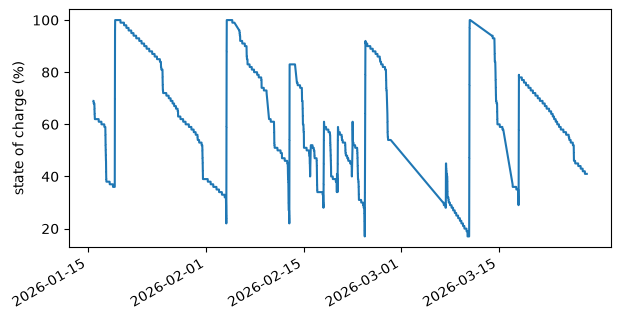

In [4]:
ax = frame['state_of_charge'].plot(figsize=(7, 3.5))
ax.set_xlabel('')
ax.set_ylabel('state of charge (%)')
plt.show()

State of charge falls over days and jumps back up at each charge, often to 100 percent.